# HW 8: Analyzing Exoplanet Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
exoplanets = pd.read_csv("exoplanet_data.csv", comment = "#")
exoplanets

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
3,DMPP-1 b,DMPP-1,0,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2025-09-25,2020-10,2025-09-25
579,bet Pic c,bet Pic,1,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2023-06-12,2022-09,2023-06-12
580,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2019-08-23,2019-08,2019-08-29
581,eps Ind A b,eps Ind A,1,3,1,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,2.237,0.240,-0.240,4.34562,0.007374,-0.007374,2024-08-07,2024-09,2024-08-07


In [6]:
print(f"The shape of the dataset is: {exoplanets.shape}. There are {exoplanets.shape[0]} rows and {exoplanets.shape[1]} columns.")

The shape of the dataset is: (583, 92). There are 583 rows and 92 columns.


In [7]:
print(exoplanets.columns)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [8]:
no_idea = ["disc_facility", "pl_bmassj", "st_tefflim", "pl_insolerr1", "st_logg"]
print(f"I have no idea what these 5 column titles (among many others) mean (yet): {no_idea}")

I have no idea what these 5 column titles (among many others) mean (yet): ['disc_facility', 'pl_bmassj', 'st_tefflim', 'pl_insolerr1', 'st_logg']


### Table Label: Planet Name
#### Database Column Name: pl_name
##### Description: "Planet name most commonly used in the literature"
##### What I'd Say: Self explanatory, planet name associated with subject

### Table Label: Host Name
#### Database Column Name: hostname
##### Description: "Stellar name most commonly used in the literature"
##### What I'd Say: name of the star the given exoplanet orbits

### Table Label: Discovery Method
#### Database Column Name: discoverymethod
##### Description: "Method by which the planet was first identified"
##### What I'd Say: How the exoplanet was discovered (I'd want to say Transit or Doppler Wobble, this data has Radial Velocity (more official I guess), Transit, Imaging, Microlensing, etc)

### Table Label: Spectral Type
#### Database Column Name: st_spectype 
##### Description: "Classification of the star based on their spectral characteristics following the Morgan-Keenan system"
##### What I'd Say: Type of star based on an HR Diagram/ star luminosity (O B A F G K M)

### Table Label: Equilibrium Temperature [K]
#### Database Column Name: pl_eqt
##### Description: "The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body"
##### What I'd Say: surface temp if it were a perfect blackbody emitter (and absorber)

### Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
#### Database Column Name: pl_bmassj
###### *** note that this column name is different from the typical one marked on the documentation website
##### Description: "Minimum mass of a planet as measured by radial velocity, measured in units of masses of Jupiter"
##### What I'd Say: least possible mass as found with doppler wobble in terms of Jupiter's mass

In [10]:
exo = exoplanets[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]
exo

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.912000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.870000
2,DMPP-1 b,DMPP-1,Radial Velocity,NaN,NaN,0.052859
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
4,DMPP-1 c,DMPP-1,Radial Velocity,NaN,NaN,0.034421
...,...,...,...,...,...,...
578,bet Pic c,bet Pic,Radial Velocity,NaN,1250.0,8.200000
579,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,10.139000
580,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,9.000000
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310000


In [13]:
print(f"The shape of the dataset is: {exo.shape}. There are {exo.shape[0]} rows and {exo.shape[1]} columns. The column names are: {exo.columns}")
exo.head(), exo.tail()

The shape of the dataset is: (583, 6). There are 583 rows and 6 columns. The column names are: Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


(    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
 0   7 CMa c    7 CMa  Radial Velocity         NaN     NaN   0.912000
 1   7 CMa c    7 CMa  Radial Velocity         NaN     NaN   0.870000
 2  DMPP-1 b   DMPP-1  Radial Velocity         NaN     NaN   0.052859
 3  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
 4  DMPP-1 c   DMPP-1  Radial Velocity         NaN     NaN   0.034421,
          pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
 578    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0      8.200
 579    bet Pic c    bet Pic  Radial Velocity         NaN     NaN     10.139
 580    bet Pic c    bet Pic  Radial Velocity         NaN     NaN      9.000
 581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
 582  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN      3.250)

In [14]:
print(exo['discoverymethod'].value_counts())

discoverymethod
Transit                      392
Radial Velocity              118
Microlensing                  61
Imaging                        6
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64


The different discovery methods are: Transit, which has the most at 392 exoplanets, Radial Velocity, with 118 exoplanets, Microlensing with 61, Imaging with 6, Transit Timing Variations with 3, Eclipse Timing Variations with 2, and Disk Kinematics with the least at just 1 exoplanet discovered this way.

Transiting: exoplanet passes in front of its star and causes a very small decrease in the brightness 

Radial Velocity: Doppler wobble (effect) on stars with exoplanet mass and shift in star spectrum / emission lines

Microlensing: star/ luminous object's light is on its way to the observer and is brightened by a lens in the middle of its path (in this case a star with an exoplanet) that effectively splits/ warmps the light and intensifies the flux as seen from earth or where observed. 

Imaging: after blocking the light from the exoplanet's host star, direct photo/ imaging to observe the exoplanet.

Transit Timing Variations: discrepancies with expected transits indicate that there is ANOTHER exoplanet with gravitational influence

Eclipse Timing Variations: like with transits, a discrepancy in the expected timing of an eclipse indicates there may be an exoplanet

Disk Kinematics: another instance of expectation vs reality but for protoplanetary disks. Unlike the other methods (to my knowledge), this discovers an exoplanet as it is forming and affects the motion of the gas in the disk. 

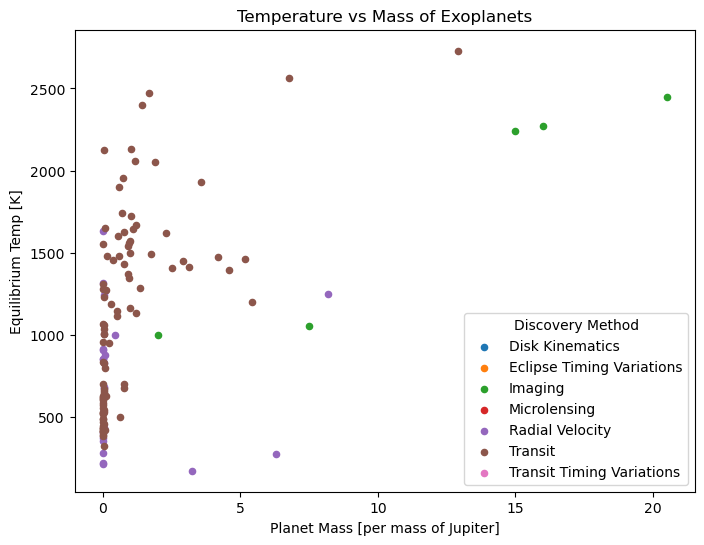

In [16]:
plt.figure(figsize = (8,6))
for method, group in exo.groupby("discoverymethod"):
    plt.scatter(
        group["pl_bmassj"],
        group["pl_eqt"],
        label=method,
        s=20
    ) # wanted to first use hue but that's a seaborn command unfortunately so for loop it is. used pandas website for groupby
plt.xlabel("Planet Mass [per mass of Jupiter]")
plt.ylabel("Equilibrium Temp [K]")
plt.title("Temperature vs Mass of Exoplanets")
plt.legend(title = "Discovery Method")
plt.show()

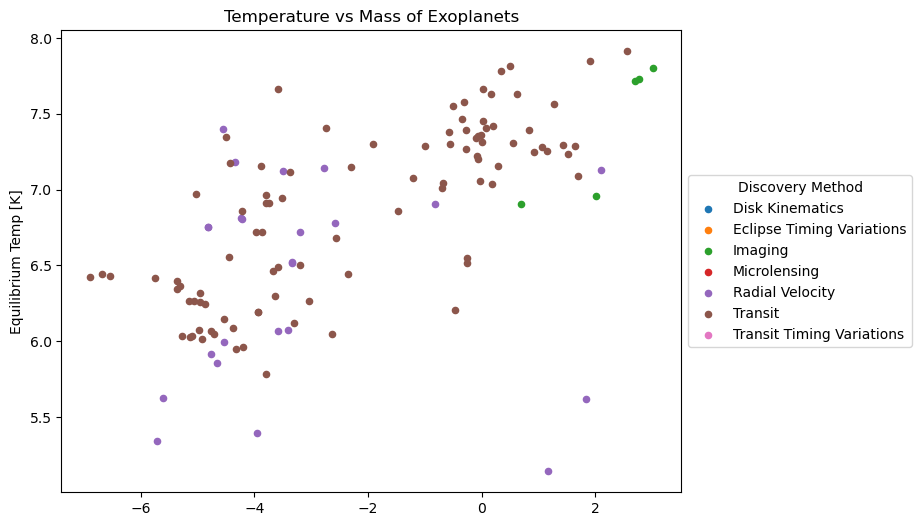

In [24]:
plt.figure(figsize = (8,6))
for method, group in exo.groupby("discoverymethod"):
    plt.scatter(
        np.log(group["pl_bmassj"]),
        np.log(group["pl_eqt"]),
        label=method,
        s=20
    ) 
plt.ylabel("Equilibrium Temp [K]")
plt.title("Temperature vs Mass of Exoplanets")
plt.legend(title = "Discovery Method",  loc="center left",
    bbox_to_anchor=(1, 0.5)) # had to google the commands to get legend to go next to the plot in order for it to not cover up legend
plt.show()

Based on this plot, the exoplanets found by the imaging method are more likely to be massive as they are closer to the right edge of the plot/ x axis

In [19]:
five_jupiter_masses = exo[exo["pl_bmassj"] > 5]
coldest_mass = five_jupiter_masses.loc[five_jupiter_masses["pl_eqt"].idxmin()]
print(coldest_mass)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


In [21]:
print(f"Name: {coldest_mass["pl_name"]}, Index: {coldest_mass.name}, Equilibrium Temperature: {coldest_mass["pl_eqt"]}, Mass: {coldest_mass["pl_bmassj"]}, Type of Star: {coldest_mass["st_spectype"]}")

Name: eps Ind A b, Index: 581, Equilibrium Temperature: 275.0, Mass: 6.31, Type of Star: K5 V


Compared to the Sun as a G2 V star, this star (K2 V) is smaller and less hot (and dimmer) but is on the main sequence like our sun. It relatively close to the Sun as G and K are neighbors in the classification system (O B A F G K M) but is not necessarily a sun-like star.

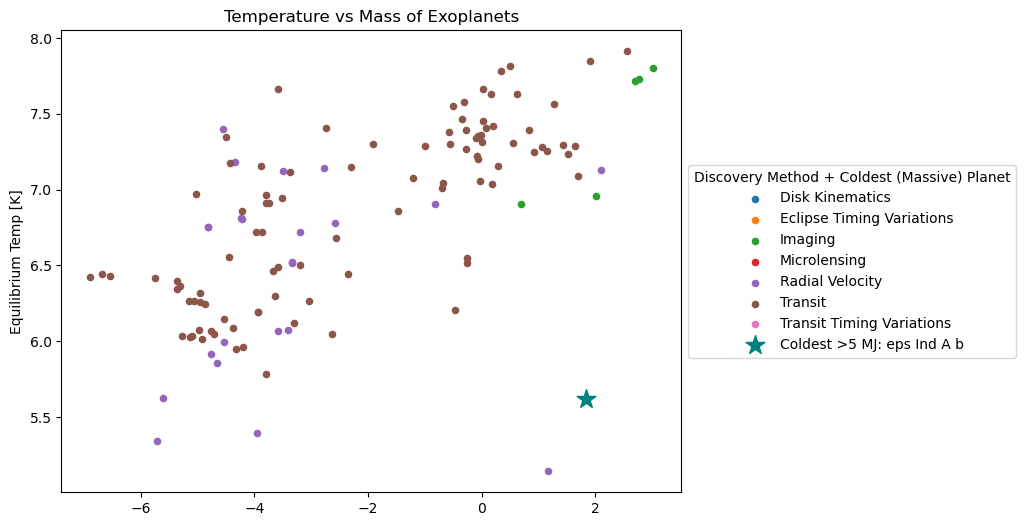

In [23]:
plt.figure(figsize = (8,6))
for method, group in exo.groupby("discoverymethod"):
    plt.scatter(
        np.log(group["pl_bmassj"]),
        np.log(group["pl_eqt"]),
        label=method,
        s=20
    ) 
plt.scatter(
    np.log(coldest_mass["pl_bmassj"]),
    np.log(coldest_mass["pl_eqt"]),
    color="teal",
    marker="*",
    s=200,
    label=f"Coldest >5 MJ: {coldest_mass['pl_name']}"
)
plt.ylabel("Equilibrium Temp [K]")
plt.title("Temperature vs Mass of Exoplanets")
plt.legend(title = "Discovery Method + Coldest (Massive) Planet", loc="center left",
    bbox_to_anchor=(1, 0.5)) # had to google the commands to get legend to go next to the plot in order for it to not cover up the star marker
plt.show()

## Nature Scientific Journal
### Paper Title: 

A temperate super-Jupiter imaged with JWST in the mid-infrared
### Abstract Summary:

Through radial velocity (doppler wobble), there is a giant exoplanet orbiting that star Eps Ind A (a K5V star as we found by isolating the row). It has the equilibrium temperature of 275 K (also found in our dataframe!). It is called Eps Ind A b despite the discrepancy/ new properties because they think there is just one giant exoplanet around this star (kind of like recycling the name but updating the properties). 

### Matches: 

I think so. The name is the same, as are the temperature and of course the star.
### What's Special? 

This Planet's brightness is what makes it so special (though we don't really have a column for this in our shaved down dataframe so I gotta just trust the paper here). 
### Parameters Match? 

Yes, Equilibrium Temperature Matches. Little hard for me to tell mass since they don't seem to have the mass in terms of Jupiter, at least in the abstract (if it is, then we have 6.31 while the paper says 3.6 but again I'm not sure this has the same units).
